In [1]:
import math
import itertools

import numpy as np
import cupy as cp
import numba as nb
import numba.cuda
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.ndimage
import rasterio
import PIL
import sklearn.linear_model
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

In [3]:
def point_in_disk(radius=50, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = x**2 + y**2 <= linewidth**2
    small_disk = np.sum(np.sum(disk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_minidisk = np.sum(np.sum(minidisk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_disk[small_minidisk > 0] = 0
    small_disk = -small_disk / np.sum(small_disk)
    small_disk[small_minidisk > 0] = 1 / np.sum(small_minidisk > 0)
    return small_disk

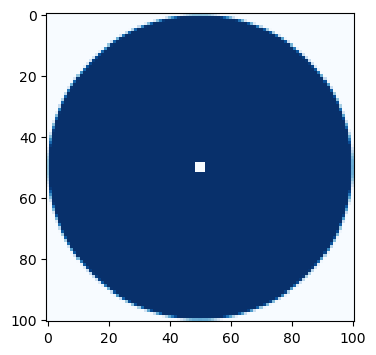

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp = point_in_disk()
ax.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")

None

In [5]:
def line_in_disk(angle, radius=50, linelength=15, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = np.exp(-(x**2 + y**2) / 2 / linelength**2) / np.sqrt(2 * np.pi * linelength**2)
    line = np.abs(x * np.sin(-angle * np.pi/180) - y * np.cos(angle * np.pi/180)) < linewidth
    centerline = minidisk * (disk & line)
    big = -(disk / np.sum(disk)) + (centerline / np.sum(centerline))
    small = np.sum(np.sum(big.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    return small

3.608224830031759e-16


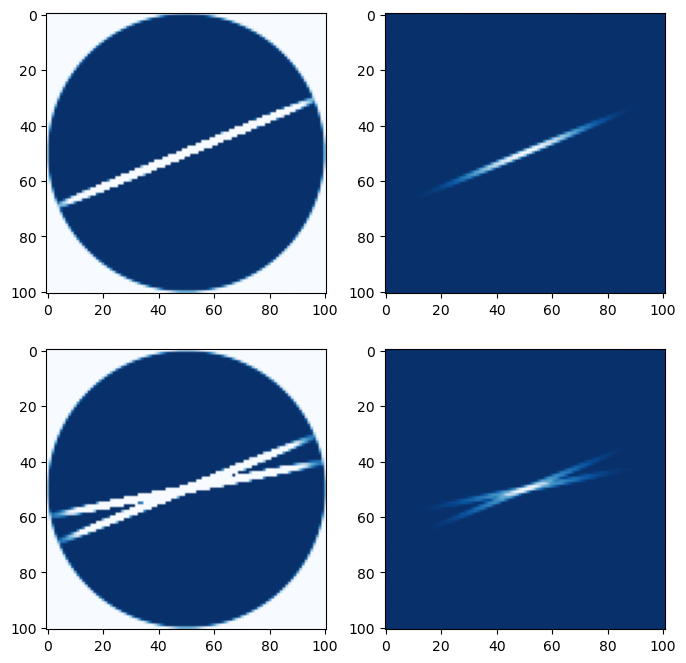

In [6]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

tmp = line_in_disk(22.5)
tmp2 = line_in_disk(11.25)
print(np.sum(tmp))

ax1.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")
ax2.imshow(tmp, vmin=0, vmax=np.nanmax(tmp), cmap="Blues_r")
ax3.imshow(tmp + tmp2, vmin=np.nanmin(tmp + tmp2), vmax=0, cmap="Blues_r")
ax4.imshow(tmp + tmp2, vmin=0, vmax=np.nanmax(tmp + tmp2), cmap="Blues_r")

None

In [7]:
with rasterio.open("../data/Sonoma_DTM_2022-OAEC-0.01-degree.tif") as file:
    elevation = file.read(1)
    transform = file.transform
    crs = file.crs

In [8]:
small_image = elevation[1800:2900, 600:1500]

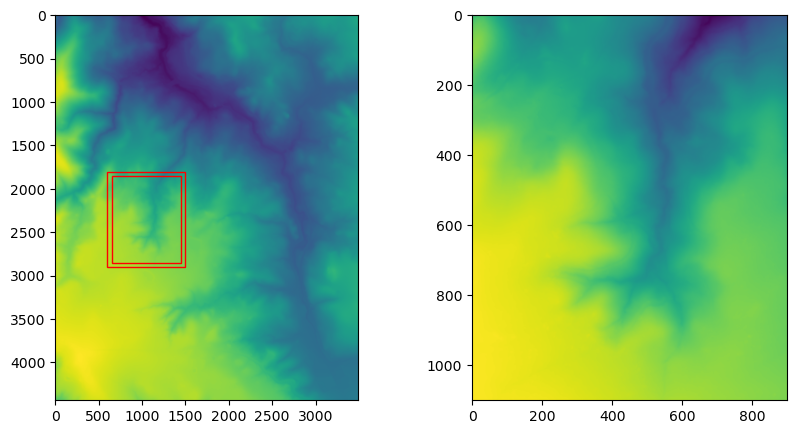

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(elevation)
ax1.add_patch(mpl.patches.Rectangle((600, 1800), 1500 - 600, 2900 - 1800, edgecolor="red", facecolor="none"))
ax1.add_patch(mpl.patches.Rectangle((600 + 50, 1800 + 50), 1500 - 600 - 100, 2900 - 1800 - 100, edgecolor="red", facecolor="none"))

ax2.imshow(small_image)

None

In [10]:
_convolve2dkernel = {}

def convolve2d(image, multikernel):
    image = cp.asarray(image, dtype=np.float32)
    multikernel = cp.asarray(multikernel, dtype=np.float32)
    output = cp.zeros(multikernel.shape[:1] + image.shape, image.dtype)

    key = (image.shape, multikernel.shape)
    if key not in _convolve2dkernel:
        imageI, imageJ = image.shape
        kernelI, kernelJ = multikernel.shape[1:]
        num_angles = multikernel.shape[0]

        @nb.cuda.jit
        def fcn(image, multikernel, output):
            ang, imi, imj = nb.cuda.grid(3)
            if imi >= imageI or imj >= imageJ:
                return

            halfi = kernelI // 2
            halfj = kernelJ // 2

            accumulate = 0
            for ki in range(kernelI):
                for kj in range(kernelJ):
                    # boundary conditions that reflect
                    i = abs(imi + ki - halfi)
                    j = abs(imj + kj - halfj)
                    i = i if i < imageI else 2*imageI - i - 1
                    j = j if j < imageJ else 2*imageJ - j - 1
                    accumulate += image[i, j] * multikernel[ang, ki, kj]

            output[ang, imi, imj] = accumulate

        _convolve2dkernel[key] = fcn

    threadsperblock = (16, 8, 8)
    blockspergrid_i = int(np.ceil(image.shape[0] / threadsperblock[1]))
    blockspergrid_j = int(np.ceil(image.shape[1] / threadsperblock[2]))
    blockspergrid = (1, blockspergrid_i, blockspergrid_j)

    _convolve2dkernel[key][blockspergrid, threadsperblock](image, multikernel, output)
    return output.get()

In [11]:
kernel5 = np.stack([line_in_disk(angle, linelength=5) for angle in np.arange(0, 180, 11.25)])
kernel10 = np.stack([line_in_disk(angle, linelength=10) for angle in np.arange(0, 180, 11.25)])
kernel15 = np.stack([line_in_disk(angle, linelength=15) for angle in np.arange(0, 180, 11.25)])
kernel20 = np.stack([line_in_disk(angle, linelength=20) for angle in np.arange(0, 180, 11.25)])

In [12]:
convolution5 = convolve2d(elevation, kernel5)[:, 50:-50, 50:-50]

In [13]:
convolution10 = convolve2d(elevation, kernel10)[:, 50:-50, 50:-50]

In [14]:
convolution15 = convolve2d(elevation, kernel15)[:, 50:-50, 50:-50]

In [15]:
convolution20 = convolve2d(elevation, kernel20)[:, 50:-50, 50:-50]

In [16]:
PIL.Image.fromarray((255 * (np.minimum(0, np.min(convolution15, axis=0)) - np.min(convolution15)) / (0 - np.min(convolution15))).astype(np.uint8)).save("../for-hand-labeling.png")

In [17]:
hand_labeled = np.asarray(PIL.Image.open("../hand-labeled.png"))[:, :, 1] / 255

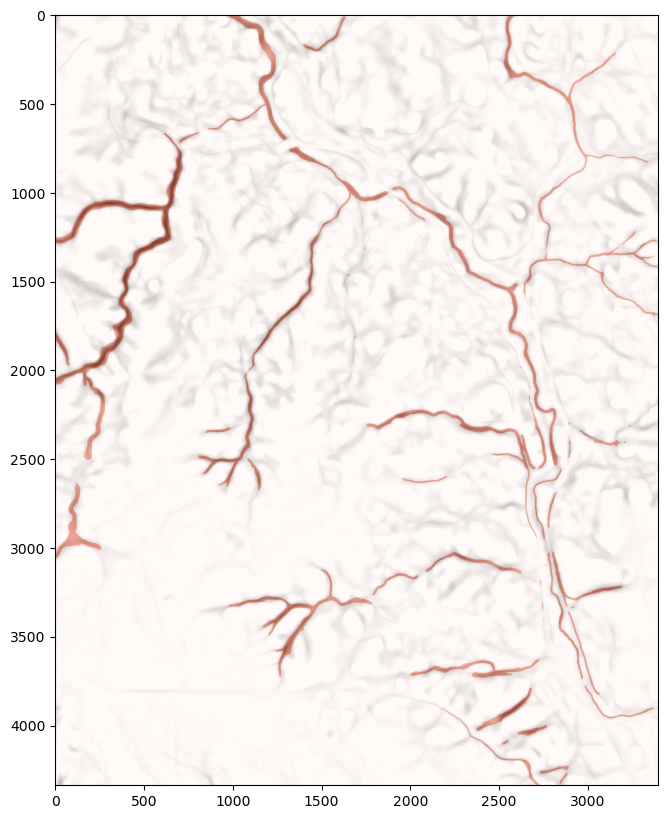

In [18]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.imshow(np.min(convolution15, axis=0), vmax=0, cmap="gray")

ax.imshow(hand_labeled > 0.5, cmap="Reds", vmin=0, vmax=2, alpha=0.5)

None

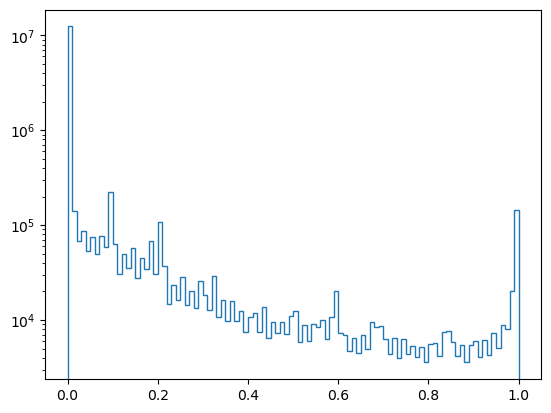

In [19]:
fig, ax = plt.subplots()

ax.hist(hand_labeled.flatten(), bins=100, range=(0, 1), histtype="step")

ax.set_yscale("log")

None

In [20]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x * 10))

def logit(x):
    return np.log(x / (1 - x)) / 10

def shrink(x):
    return x * (1 - 2e-4) + 1e-4

def grow(x):
    return (x - 1e-4) / (1 - 2e-4)

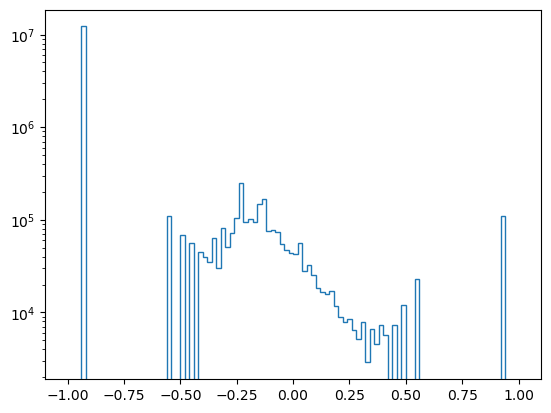

In [21]:
fig, ax = plt.subplots()

ax.hist(logit(shrink(hand_labeled)).flatten(), bins=100, range=(-1, 1), histtype="step")

ax.set_yscale("log")

None

In [22]:
abs(grow(sigmoid(logit(shrink(hand_labeled)))) - hand_labeled).max()

np.float64(2.220446049250313e-16)

In [23]:
SIN_PI_8  = np.sin(np.pi/8)
COS_PI_8  = np.cos(np.pi/8)
SQRT1_2   = np.sqrt(1/2)
INV16 = 1/16
INV8  = 1/8

def best_fit(y0, y1, y2, y3, y4, y5, y6, y7, y8, y9, y10, y11, y12, y13, y14, y15):
    # Constant term is the mean
    A = INV16 * (y0 + y1 + y2 + y3 + y4 + y5 + y6 + y7 + y8 + y9 + y10 + y11 + y12 + y13 + y14 + y15)

    # Sine projection:
    # sin(k*pi/8) over k=0..15 is:
    # [0, s, m, c, 1, c, m, s, 0, -s, -m, -c, -1, -c, -m, -s]
    t_s = (y1 + y7)  - (y9 + y15)    # weights with ±sin(pi/8)
    t_m = (y2 + y6)  - (y10 + y14)   # weights with ±sqrt(1/2)
    t_c = (y3 + y5)  - (y11 + y13)   # weights with ±cos(pi/8)
    t_1 =  y4 - y12                  # weights with ±1
    S_sum = (SIN_PI_8 * t_s) + (SQRT1_2 * t_m) + (COS_PI_8 * t_c) + t_1
    B = INV8 * S_sum

    # Cosine projection:
    # cos(k*pi/8) over k=0..15 is:
    # [1, c, m, s, 0, -s, -m, -c, -1, -c, -m, -s, 0,  s,  m,  c]
    u_1 =  y0 - y8                   # weights with ±1
    u_c = (y1 + y15) - (y7 + y9)     # weights with ±cos(pi/8)
    u_m = (y2 + y14) - (y6 + y10)    # weights with ±sqrt(1/2)
    u_s = (y3 + y13) - (y5 + y11)    # weights with ±sin(pi/8)
    C_sum = u_1 + (COS_PI_8 * u_c) + (SQRT1_2 * u_m) + (SIN_PI_8 * u_s)
    C = INV8 * C_sum

    return A, B, C

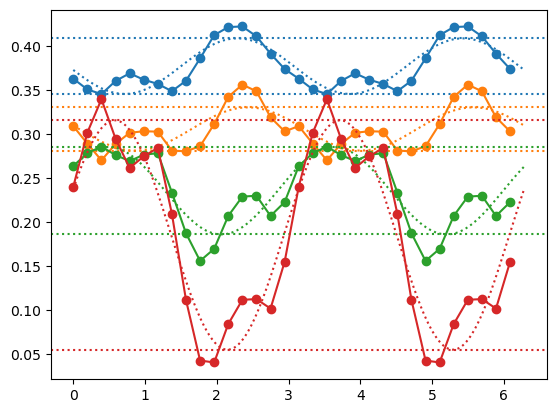

In [24]:
fig, ax = plt.subplots()

_, i, j = sorted([
    (convolution15[:, i, j].min(), i, j)
     for i, j in zip(np.random.randint(0, convolution15.shape[1], 100000), np.random.randint(0, convolution15.shape[2], 100000))
])[0]

i, j = np.random.randint(0, convolution15.shape[1]), np.random.randint(0, convolution15.shape[2])

def draw(convolution, color):
    pixel = convolution[:, i, j]

    x = np.arange(0, 180, 11.25) * np.pi/180
    ax.plot(x.tolist() + (x + np.pi).tolist(), pixel.tolist() * 2, marker="o", color=color)
    
    A, B, C = best_fit(*pixel)
    x = np.linspace(0, 2*np.pi, 320)
    y = A + B*np.sin(2*x) + C*np.cos(2*x)
    ax.plot(x, y, color=color, ls=":")

    ax.axhline(A - np.sqrt(B**2 + C**2), color=color, ls=":")
    ax.axhline(A + np.sqrt(B**2 + C**2), color=color, ls=":")

draw(convolution5, color=default_colors[0])

draw(convolution10, color=default_colors[1])

draw(convolution15, color=default_colors[2])

draw(convolution20, color=default_colors[3])

None

In [25]:
min5, max5 = np.min(convolution5, axis=0), np.max(convolution5, axis=0)
min10, max10 = np.min(convolution10, axis=0), np.max(convolution10, axis=0)
min15, max15 = np.min(convolution15, axis=0), np.max(convolution15, axis=0)
min20, max20 = np.min(convolution20, axis=0), np.max(convolution20, axis=0)

In [26]:
A, B, C = best_fit(*convolution5)
low5, high5 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In [27]:
A, B, C = best_fit(*convolution10)
low10, high10 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In [28]:
A, B, C = best_fit(*convolution15)
low15, high15 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In [29]:
A, B, C = best_fit(*convolution20)
low20, high20 = A - np.sqrt(B**2 + C**2), A + np.sqrt(B**2 + C**2)

In [30]:
features = ["min5", "min15", "low5", "high5 - low5", "low15", "high15 - low15", "low5 * (high5 - low5)", "low5 * (high15 - low15)", "low15 * (high5 - low5)", "low15 * (high15 - low15)"]

X = np.stack([eval(x) for x in features]).reshape(len(features), -1).T
Y = logit(shrink(hand_labeled)).reshape(-1)

In [31]:
for feature, values in zip(features, X.T):
    print(f"{feature:25s}", np.percentile(values, [0, 25, 50, 75, 100]).tolist())

min5                      [-10.661192893981934, -0.5683707445859909, -0.023607931099832058, 0.48841898143291473, 14.833091735839844]
min15                     [-9.204473495483398, -0.6335967183113098, -0.10882527008652687, 0.23740119487047195, 9.993380546569824]
low5                      [-10.645414934471312, -0.5615313074586732, -0.019799503216258445, 0.49302500696509155, 14.861059899283735]
high5 - low5              [9.732663669437258e-06, 0.04284881314248967, 0.08500959830563021, 0.15595187338988015, 2.730365234058876]
low15                     [-8.934354145506049, -0.6016482884460983, -0.09289931259328393, 0.25357948413996734, 10.048469797088599]
high15 - low15            [2.9200303805265726e-05, 0.15477402967839582, 0.3243409545975747, 0.5751751525992187, 6.029964690147502]
low5 * (high5 - low5)     [-16.080175047329035, -0.04894542922347811, -0.0005053873507183047, 0.03578181416615407, 25.384901016671996]
low5 * (high15 - low15)   [-45.795766050103886, -0.17469827483480216, -0.00

In [32]:
X_scaled = (X - np.min(X, axis=0, keepdims=True)) / np.ptp(X, axis=0, keepdims=True) * 2 - 1

In [33]:
for feature, values in zip(features, X_scaled.T):
    print(f"{feature:25s}", np.percentile(values, [0, 25, 50, 75, 100]))

min5                      [-1.         -0.20822864 -0.16549257 -0.12532459  1.        ]
min15                     [-1.         -0.10710054 -0.05243073 -0.01636145  1.        ]
low5                      [-1.         -0.20930794 -0.16682995 -0.12661863  1.        ]
high5 - low5              [-1.         -0.96862014 -0.93773714 -0.88577155  1.        ]
low15                     [-1.         -0.12207942 -0.06847845 -0.03197399  1.        ]
high15 - low15            [-1.         -0.94867447 -0.89243276 -0.80923645  1.        ]
low5 * (high5 - low5)     [-1.         -0.22675991 -0.22442348 -0.22267323  1.        ]
low5 * (high15 - low15)   [-1.          0.13111549  0.13541587  0.13887914  1.        ]
low15 * (high5 - low5)    [-1.         -0.02733246 -0.02370724 -0.02239886  1.        ]
low15 * (high15 - low15)  [-1.          0.3542146   0.36030736  0.36241065  1.        ]


In [34]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device="cuda:0")
Y_tensor = torch.tensor(Y[:, np.newaxis], dtype=torch.float32, device="cuda:0")

In [51]:
model = nn.Sequential(
    nn.Linear(X_tensor.shape[1], 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 1),
).to("cuda:0")

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

losses = []
for epoch in range(1000):
    optimizer.zero_grad()
    prediction = model(X_tensor)
    loss = loss_fn(prediction, Y_tensor)
    losses.append(float(loss))
    loss.backward()
    optimizer.step()

with torch.no_grad():
    prediction = model(X_tensor).cpu().numpy()

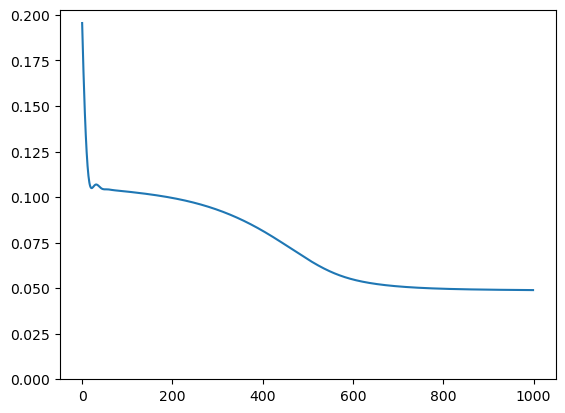

In [52]:
fig, ax = plt.subplots()

ax.plot(range(len(losses)), losses)

ax.set_ylim(0, ax.get_ylim()[1])

None

In [44]:
fit = sklearn.linear_model.LinearRegression()
fit.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
for feature, parameter in zip(features, fit.coef_):
    print(f"{feature:25s} {parameter:6.3f}")

min5                       0.135
min15                     -0.772
low5                       0.115
high5 - low5              -0.012
low15                      0.348
high15 - low15             0.188
low5 * (high5 - low5)     -0.102
low5 * (high15 - low15)   -0.110
low15 * (high5 - low5)     0.168
low15 * (high15 - low15)   0.099


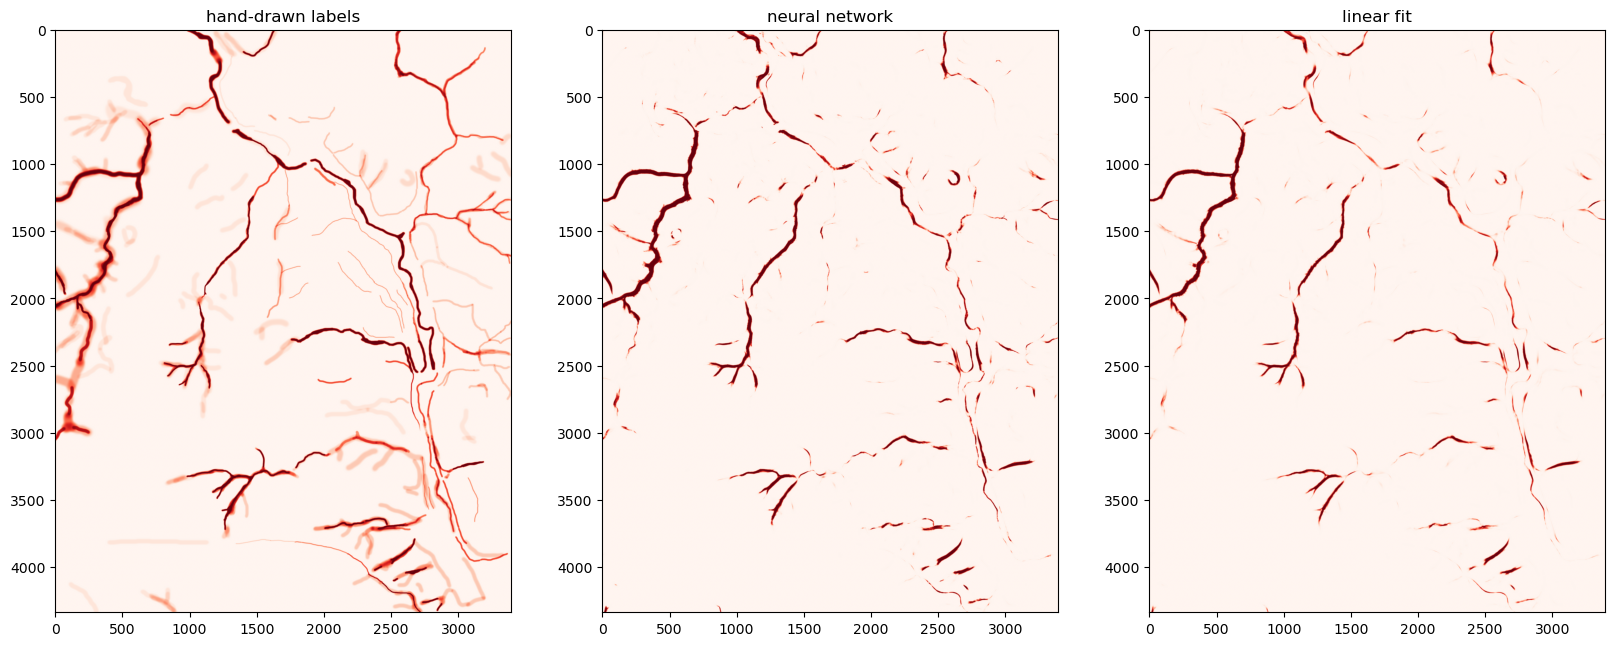

In [57]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 10))

ax1.imshow(hand_labeled, cmap="Reds", vmin=0, vmax=1)
ax1.set_title("hand-drawn labels")

ax2.imshow(grow(sigmoid(prediction)).reshape(hand_labeled.shape), cmap="Reds", vmin=0, vmax=1)
ax2.set_title("neural network")

ax3.imshow(grow(sigmoid(fit.predict(X))).reshape(hand_labeled.shape), cmap="Reds", vmin=0, vmax=1)
ax3.set_title("linear fit")

None

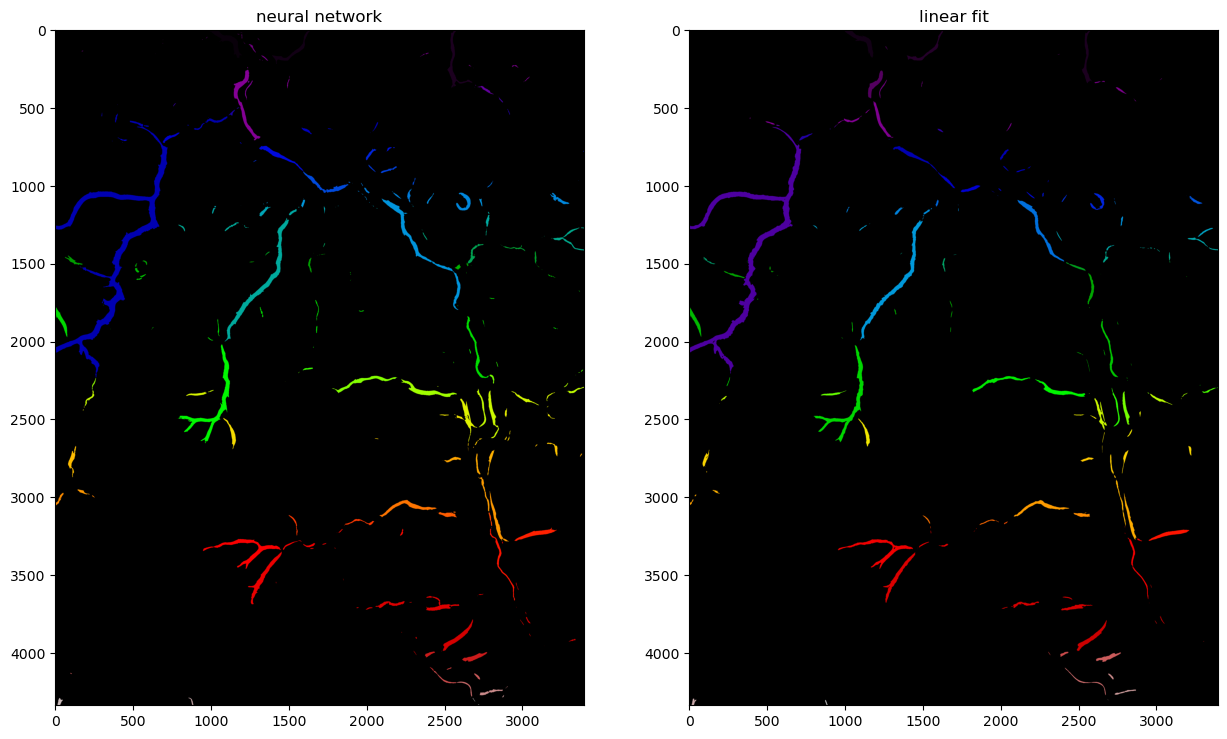

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

all8corners = scipy.ndimage.generate_binary_structure(2, 2)

ax1.imshow(scipy.ndimage.label(grow(sigmoid(prediction)).reshape(hand_labeled.shape) > 0.25, all8corners)[0], vmin=0, cmap="nipy_spectral")
ax1.set_title("neural network")

ax2.imshow(scipy.ndimage.label(grow(sigmoid(fit.predict(X))).reshape(hand_labeled.shape) > 0.25, all8corners)[0], vmin=0, cmap="nipy_spectral")
ax2.set_title("linear fit")

None